In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/gsv3", token=api_key)

Loaded as API: https://verdantintel-gsv3.hf.space


# Helper Function

In [3]:
def parse_events(text):

    events = []

    for block in text.strip().split("\n\n"):
        lines = block.split("\n")

        event = {"title": lines[0].strip()}

        for line in lines[1:]:
            if ":" in line:
                key, value = line.split(":", 1)
                key = key.strip().lower().replace(" ", "_")
                value = value.strip()
                event[key] = value

        events.append(event)

    return events

In [4]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    #answer = ast.literal_eval(answer)
    events = parse_events(answer)

    return events

    #return answer

# Searching for Data

In [20]:
question = 'what punk shows happen in Portland?'
question = 'what events happen in Japan?'

answer = ask_api(client, question)
len(answer)

93

In [21]:
answer[0]

{'title': '世界望郷の旅 Journey to World Nostalgia',
 'performers': 'Lee Swee Keong, Moon Moon Singh, 今井尋也, 池野拓哉, 綾田將一, 壱弥, 津山舞花, ジャスティス エドワーズ, 河合ケネディ',
 'event_dates': '21 June 2026, 01:30 PM',
 'price': 'JPY 3,000',
 'venue': 'ザ・スズナリ',
 'location': 'Setagaya, Japan',
 'contact_information': 'hkbpyoyaku@gmail.com',
 'description': 'The event is a performance titled "Journey to World Nostalgia," directed by Hiroshi Koike. It explores themes of memory, reality, and humanity through the story of young individuals facing a predetermined fate.',
 'genres': 'Theatre, Dance, Performing Arts, Contemporary Dance',
 'source_url': 'https://allevents.in/setagaya/世界望郷の旅-journey-to-world-nostalgia-tickets/80002904506944'}

# Going Out Methodology

- Fetch GrooveSeeker events (done)
- Read quickly with my eyes looking for interesting things
- Reduce to a few options that I am actually interest in
- Go have fun

The test of GrooveSeeker is whether or not it leads to things that I enjoy. The technical tests are already done.

In [22]:
answer[0:2]

[{'title': '世界望郷の旅 Journey to World Nostalgia',
  'performers': 'Lee Swee Keong, Moon Moon Singh, 今井尋也, 池野拓哉, 綾田將一, 壱弥, 津山舞花, ジャスティス エドワーズ, 河合ケネディ',
  'event_dates': '21 June 2026, 01:30 PM',
  'price': 'JPY 3,000',
  'venue': 'ザ・スズナリ',
  'location': 'Setagaya, Japan',
  'contact_information': 'hkbpyoyaku@gmail.com',
  'description': 'The event is a performance titled "Journey to World Nostalgia," directed by Hiroshi Koike. It explores themes of memory, reality, and humanity through the story of young individuals facing a predetermined fate.',
  'genres': 'Theatre, Dance, Performing Arts, Contemporary Dance',
  'source_url': 'https://allevents.in/setagaya/世界望郷の旅-journey-to-world-nostalgia-tickets/80002904506944'},
 {'title': '神戸港ウィークエンド花火',
  'performers': 'Not provided in source.',
  'event_dates': 'May 2, 2026 at 19:30, May 16, 2026 at 19:30, June 6, 2026 at 19:30, June 20, 2026 at 19:30, July 4, 2026 at 19:30, July 18, 2026 at 19:30, July 28, 2026 at 18:30, August 1, 2026 at 19:30, 

Let's loop through titles and see what looks interesting. I don't want to be distracted by the other context yet. Title and descriptiona re good enough.

In [23]:
df = pd.DataFrame(answer)

df = df[df['source_url'].str.startswith('https')] # simple URL filter; drop empties; the rest are https

df.drop_duplicates(inplace=True)
df.sort_values('title', inplace=True)

for row in df.iterrows():
    
    title = row[1]['title']
    description = row[1]['description']
    event_dates = row[1]['event_dates']
    
    url = row[1]['source_url']
    
    print(title)
    print()
    print(event_dates)
    print()
    print(description)
    print()
    print(url)
    print()
    print('-------------------------------------------------')
    print()

**Rose Parade**

January 1, 2026

The Rose Parade features large marching bands from various schools, including Allen Eagle Escadrille from Texas and Mino Jiyu Gakuen from Japan. These bands invest significant effort in fundraising and logistics to participate in the parade, which is a prestigious event showcasing their musical talents to millions of viewers.

https://www.pasadenastarnews.com/2025/12/08/how-do-bands-make-the-rose-parade-after-tears-turn-to-joy-come-pizza-sales-sponsorships-and-march-a-thons/

-------------------------------------------------

2026 TXT Moa Con In Japan: Live Viewing

May 24, 2026, 2:45 PM

Fans of Tomorrow X Together (TXT) can catch a special concert live from Japan celebrating the group's seventh anniversary. The event is a global live-stream featuring performances of fan favorites, live-band arrangements, and special solo stages.

https://straitstimes.com/life/entertainment/chaos-and-hilarity-abound-with-k-stars-park-seo-joon-and-choi-woo-shik-in-unpl

Since writing the article, I often come back to this notebook to look up fun events. 

I used a similar notebook to go to a show: https://100daysofnetworks.substack.com/p/day-81-of-100daysofnetworks
I will use this to find more bands and shows

# Data Science Exploration

This time, I wanna go a bit further and see what I can do. I wonder if I can use bipartite projection
to learn more about the ecosystem, but converting this into a social graph and a venue graph.

In [24]:
# for graph
import networkx as nx

# for bipartite projection
from networkx.algorithms import bipartite

# for visualization
import numpy as np
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=True, node_size=5, font_size=10, edge_width=1, scores=True):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores=scores, edge_width=edge_width)
    
    return SVG(image)

In [25]:
edgelist_df = df[['performers', 'venue']].copy()
edgelist_df['performers'] = edgelist_df['performers'].apply(lambda s: s.split(','))
edgelist_df = edgelist_df.explode('performers')
edgelist_df.head()

,performers,venue
55,Allen Eagle Escadrille Marching Band,Not provided in source.
55,Mino Jiyu Gakuen High School Marching Band,Not provided in source.
90,Tomorrow X Together (TXT),Shaw Theatres and Golden Village cinemas
91,Alex Warren,Various venues
40,Not provided in source.,Medford Library


# Bipartite Projection: Social Network

First, I will create a bipartite graph and then convert it into a social network.

In [26]:
B = nx.from_pandas_edgelist(edgelist_df, source='performers', target='venue')
G_artists = bipartite.projected_graph(B, edgelist_df['performers'])

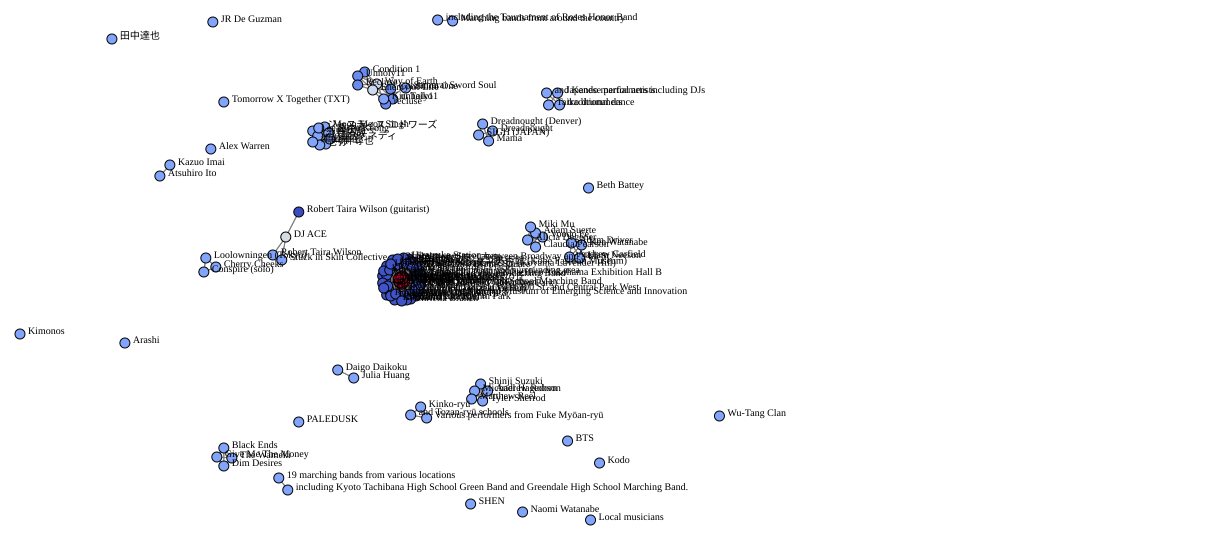

In [27]:
draw_graph(G_artists)

In [28]:
sorted(G_artists.nodes) # Artists that are related to Punk Rock and pass through Portland, Oregon

[' Adam Driver',
 ' Adam Suerte',
 ' Adeliia Petrosian',
 ' Alicia Degener',
 ' Ami Nakai',
 ' Andrew Robson',
 ' Atsuhiro Ito',
 ' Cherry Cheeks',
 ' Claudia Pearson',
 ' Conspire (solo)',
 ' DJ ACE',
 ' Dim Desires',
 ' Dreadnought',
 ' Dreadnought (Denver)',
 ' Enemy of Life',
 ' Give Me The Money',
 ' Julia Huang',
 ' Kaori Sakamoto',
 ' Ken Watanabe',
 ' Kinko-ryū',
 ' Liam Neeson',
 ' Mania',
 ' Matthew Reel',
 ' Michael Hagedorn',
 ' Miki Mu',
 ' Mino Jiyu Gakuen High School Marching Band',
 ' Mone Chiba',
 ' Moon Moon Singh',
 ' Recluse',
 ' Robert Taira Wilson',
 ' Samurai Sword Soul',
 ' Taiko drummers',
 ' The Wameki',
 ' Tyler Sherrod',
 ' Unholy11',
 ' Way of Earth',
 ' and Kendo martial artists.',
 ' and Tozan-ryū schools',
 ' including Kyoto Tachibana High School Green Band and Greendale High School Marching Band.',
 ' including the Tournament of Roses Honor Band',
 ' recluse',
 ' traditional dance',
 ' unholy11',
 ' ジャスティス エドワーズ',
 ' 今井尋也',
 ' 壱弥',
 ' 池野拓哉',
 ' 河合ケネディ',

C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 27827 (\N{CJK UNIFIED IDEOGRAPH-6CB3}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 12493 (\N{KATAKANA LETTER NE}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 12451 (\N{KATAKANA LETTER SMALL I}) miss

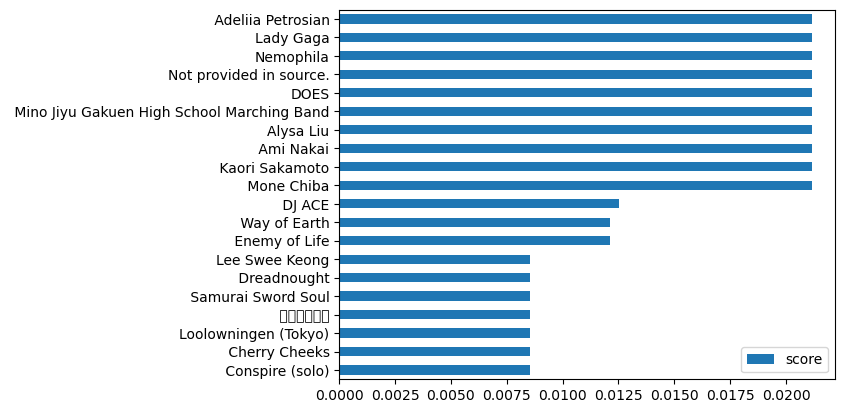

In [29]:
score_df = pd.DataFrame([nx.pagerank(G_artists)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df = score_df[1:]
score_df.head(20).plot.barh().invert_yaxis()

# Bipartite Projection: Social Network

Next, I will create a bipartite graph and then convert it into a venue network.

This shows that looking at things from different perspectives can be interesting.

It's the same bipartite graph looked at from a different perspective.

In [30]:
B = nx.from_pandas_edgelist(edgelist_df, source='performers', target='venue')
G_venue = bipartite.projected_graph(B, edgelist_df['venue'])

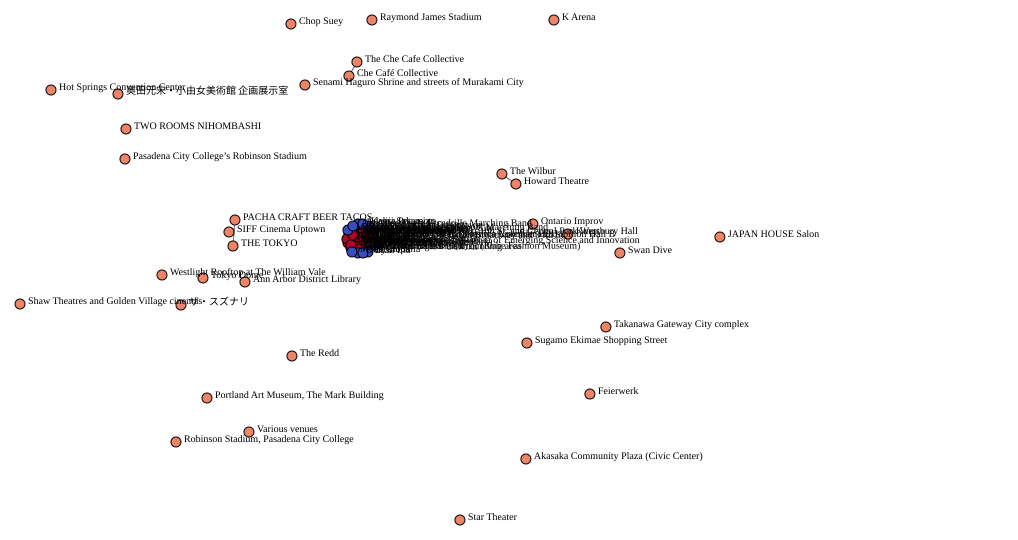

In [31]:
draw_graph(G_venue)

In [32]:
sorted(G_venue.nodes) # Artists that are related to Punk Rock and pass through Portland, Oregon

[' Adeliia Petrosian',
 ' Ami Nakai',
 ' Kaori Sakamoto',
 ' Mino Jiyu Gakuen High School Marching Band',
 ' Mone Chiba',
 '3Labs',
 '831 SE Salmon St',
 'Akasaka Community Plaza (Civic Center)',
 'Allen Eagle Escadrille Marching Band',
 'Alysa Liu',
 'Ann Arbor District Library',
 'Boston Common',
 'Central Park Entrance at West 100 St. and Central Park West',
 'Che Café Collective',
 'Chop Suey',
 'DOES',
 'Dallas Marriott Downtown',
 'Feierwerk',
 'George J. Doizaki Gallery',
 'Heian Jingu Shrine',
 'Henrietta Branch',
 'Hiratsuka Station',
 'Hot Springs Convention Center',
 'Howard Theatre',
 'IG Arena',
 'Ikutama Shrine',
 'JAPAN HOUSE Salon',
 'Japan House',
 'Japan House Los Angeles',
 'Japan Village',
 'Japan Village at Industry City',
 'K Arena',
 'KOHO Co-Creative Hub',
 'Kamakura Kaihin Park',
 'Kanayama Shrine',
 'Kingsbury Hall',
 'Kurihama',
 'Lady Gaga',
 'Lake Biwa',
 'Main Island',
 'Medford Library',
 'Miraikan - The National Museum of Emerging Science and Innovation'

C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 32209 (\N{CJK UNIFIED IDEOGRAPH-7DD1}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\events.py:93: UserWarning: Glyph 19992 (\N{CJK UNIFIED IDEOGRAPH-4E18}) missing from current font.
  func(*args, **kwargs)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32209 (\N{CJK UNIFIED IDEOGRAPH-7DD1}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\itsgo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: 

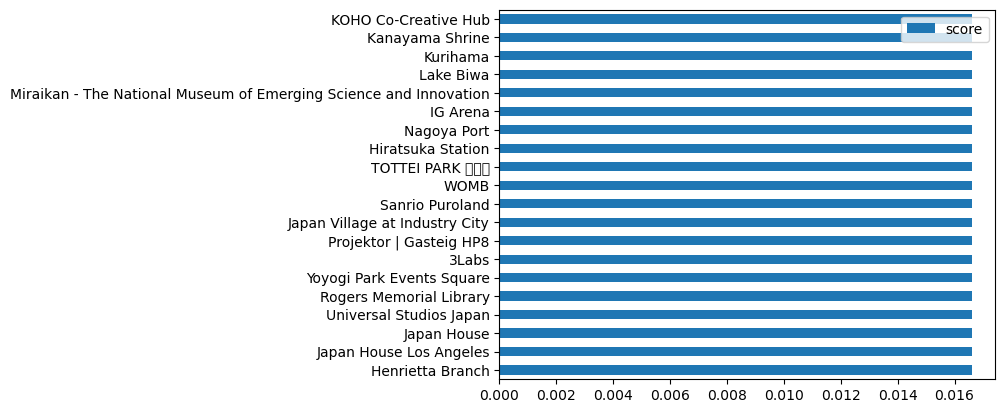

In [33]:
score_df = pd.DataFrame([nx.pagerank(G_venue)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df = score_df[1:]
score_df.head(20).plot.barh().invert_yaxis()

# I guess I should check these places out!

# Next Steps

Learn more! Listen to the bands on Youtube and other platforms and find bands that you enjoy. Look up information about vanues, and then go to them to see what you like.

Maybe I should add in Youtube search or Spotify search to learn more. There are Python libraries.